# Lesson 29: PyTorch neural network demonstration part 1
## Notebook set-up
### Imports

In [1]:
# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# Set random seeds for reproducibility
torch.manual_seed(315)
np.random.seed(315)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Load preprocessed data

In [2]:
data = pd.read_pickle('https://gperdrizet.github.io/FSA_devops/assets/data/unit4/preprocessed_housing_data.pkl')

training_df = data['training_df']
testing_df = data['testing_df']
features = data['features']
label = data['label']

print(f'Training samples: {len(training_df)}')
print(f'Testing samples: {len(testing_df)}')
print(f'Features: {features}')
print(f'Label: {label}')

Training samples: 15480
Testing samples: 5160
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Label: MedHouseVal


## 2. PyTorch nn.Sequential model

The `nn.Sequential` container is the simplest way to build a neural network in PyTorch. It allows you to create models layer-by-layer in a linear stack, similar to Keras Sequential API.

### 2.1. Prepare PyTorch tensors

In [3]:
# Convert dataframes to PyTorch tensors and move to device
X_train = torch.tensor(training_df[features].values, dtype=torch.float32).to(device)
y_train = torch.tensor(training_df[label].values, dtype=torch.float32).unsqueeze(1).to(device)
X_test = torch.tensor(testing_df[features].values, dtype=torch.float32).to(device)
y_test = torch.tensor(testing_df[label].values, dtype=torch.float32).unsqueeze(1).to(device)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: torch.Size([15480, 8])
y_train shape: torch.Size([15480, 1])
X_test shape: torch.Size([5160, 8])
y_test shape: torch.Size([5160, 1])


### 2.2. Build model

In [4]:
sequential_model = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 1)
).to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(sequential_model.parameters(), lr=2e-2)

print(sequential_model)

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=1, bias=True)
)


### 2.3. Define training function

In [5]:
def train_model(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    epochs: int = 50,
    print_every: int = 5
) -> dict[str, list[float]]:
    '''Basic training loop for PyTorch model.'''
    
    history = {'loss': [], 'r2': []}
    
    for epoch in range(epochs):
        # Set model to training mode
        model.train()
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(X_train)
        
        # Calculate loss
        loss = criterion(predictions, y_train)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Calculate R²
        with torch.no_grad():
            ss_res = torch.sum((y_train - predictions) ** 2)
            ss_tot = torch.sum((y_train - torch.mean(y_train)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
        
        # Record metrics
        history['loss'].append(loss.item())
        history['r2'].append(r2.item())
        
        # Print progress
        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(f'Epoch {epoch+1}/{epochs} - loss: {loss.item():.4f} - R²: {r2.item():.4f}')
    
    print('\nTraining complete.')
    return history

### 2.4. Train model

In [6]:
sequential_history = train_model(
    model=sequential_model,
    X_train=X_train,
    y_train=y_train,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100,
    print_every=10
)

Epoch 1/100 - loss: 0.9738 - R²: 0.0262
Epoch 10/100 - loss: 0.4279 - R²: 0.5721
Epoch 20/100 - loss: 0.3461 - R²: 0.6539
Epoch 30/100 - loss: 0.3147 - R²: 0.6853
Epoch 40/100 - loss: 0.2957 - R²: 0.7043
Epoch 50/100 - loss: 0.2788 - R²: 0.7212
Epoch 60/100 - loss: 0.2691 - R²: 0.7309
Epoch 70/100 - loss: 0.2629 - R²: 0.7371
Epoch 80/100 - loss: 0.2579 - R²: 0.7421
Epoch 90/100 - loss: 0.2577 - R²: 0.7423
Epoch 100/100 - loss: 0.2547 - R²: 0.7453

Training complete.


### 2.5. Learning curve

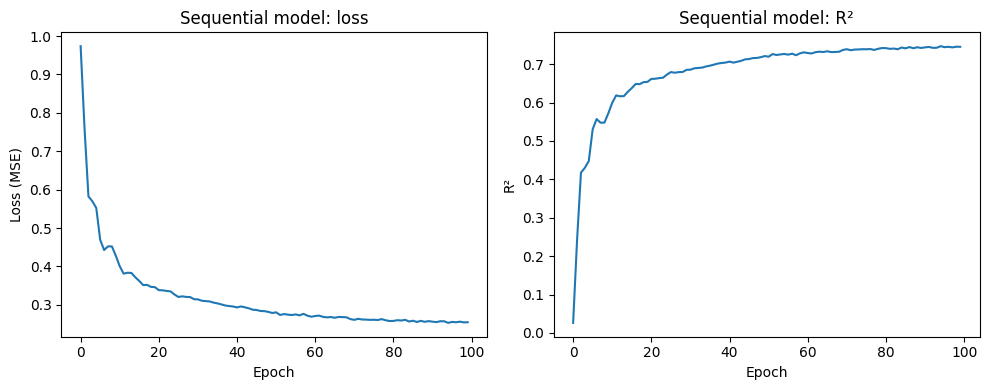

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Sequential model: loss')
axes[0].plot(sequential_history['loss'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')

axes[1].set_title('Sequential model: R²')
axes[1].plot(sequential_history['r2'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

### 2.6. Test set evaluation

In [8]:
# Set model to evaluation mode
sequential_model.eval()

# Make predictions (no gradient calculation needed)
with torch.no_grad():
    sequential_predictions = sequential_model(X_test).cpu().numpy().flatten()

# Calculate R²
ss_res = np.sum((testing_df[label].values - sequential_predictions) ** 2)
ss_tot = np.sum((testing_df[label].values - np.mean(testing_df[label].values)) ** 2)
sequential_rsquared = 1 - (ss_res / ss_tot)

print(f'Sequential model R² on test set: {sequential_rsquared:.4f}')

Sequential model R² on test set: 0.7670


### 2.7. Performance analysis

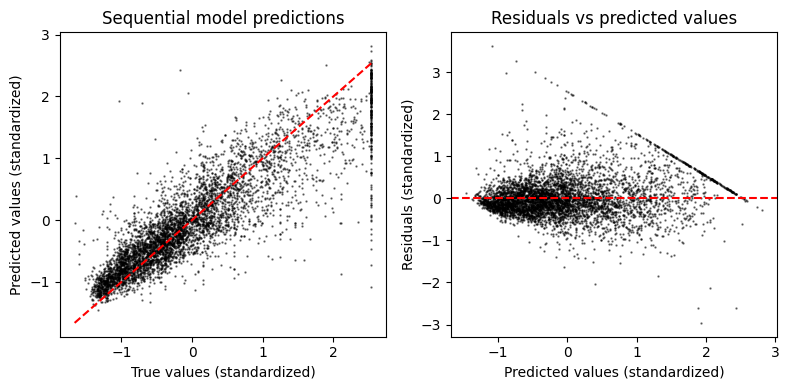

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].set_title('Sequential model predictions')
axes[0].scatter(
    testing_df[label], sequential_predictions,
    c='black', s=0.5, alpha=0.5
)
axes[0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)
axes[0].set_xlabel('True values (standardized)')
axes[0].set_ylabel('Predicted values (standardized)')

axes[1].set_title('Residuals vs predicted values')
axes[1].scatter(
    sequential_predictions, testing_df[label] - sequential_predictions,
    c='black', s=0.5, alpha=0.5
)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted values (standardized)')
axes[1].set_ylabel('Residuals (standardized)')

plt.tight_layout()
plt.show()

## 3. PyTorch nn.Module class-based model

The `nn.Module` class provides more flexibility than `nn.Sequential`. It allows you to create models via subclassing with custom forward methods, non-linear topology, shared layers, and multiple inputs or outputs, similar to the Keras Functional API.

### 3.1. Build model

In [10]:
class FunctionalMLP(nn.Module):
    '''Multi-layer perceptron using nn.Module (similar to Keras Functional API).'''
    
    def __init__(self, input_size=8):

        # Initialize parent class
        super(FunctionalMLP, self).__init__()
        
        # Define layers
        self.hidden_1 = nn.Linear(input_size, 64)
        self.dropout_1 = nn.Dropout(0.2)
        self.hidden_2 = nn.Linear(64, 32)
        self.dropout_2 = nn.Dropout(0.2)
        self.output = nn.Linear(32, 1)
        
        # Activation function
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.hidden_1(x))
        x = self.dropout_1(x)
        x = self.relu(self.hidden_2(x))
        x = self.dropout_2(x)
        x = self.output(x)
        return x

# Create model instance
functional_model = FunctionalMLP(input_size=8).to(device)

# Define loss function and optimizer
functional_criterion = nn.MSELoss()
functional_optimizer = optim.Adam(functional_model.parameters(), lr=2e-2)

print(functional_model)

FunctionalMLP(
  (hidden_1): Linear(in_features=8, out_features=64, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (hidden_2): Linear(in_features=64, out_features=32, bias=True)
  (dropout_2): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


### 3.2. Train model

In [11]:
functional_history = train_model(
    model=functional_model,
    X_train=X_train,
    y_train=y_train,
    criterion=functional_criterion,
    optimizer=functional_optimizer,
    epochs=100,
    print_every=10
)

Epoch 1/100 - loss: 1.0399 - R²: -0.0399
Epoch 10/100 - loss: 0.4473 - R²: 0.5527
Epoch 20/100 - loss: 0.3571 - R²: 0.6429
Epoch 30/100 - loss: 0.3212 - R²: 0.6788
Epoch 40/100 - loss: 0.3051 - R²: 0.6949
Epoch 50/100 - loss: 0.2926 - R²: 0.7074
Epoch 60/100 - loss: 0.2807 - R²: 0.7193
Epoch 70/100 - loss: 0.2726 - R²: 0.7274
Epoch 80/100 - loss: 0.2644 - R²: 0.7356
Epoch 90/100 - loss: 0.2611 - R²: 0.7389
Epoch 100/100 - loss: 0.2549 - R²: 0.7451

Training complete.


### 3.3. Learning curve

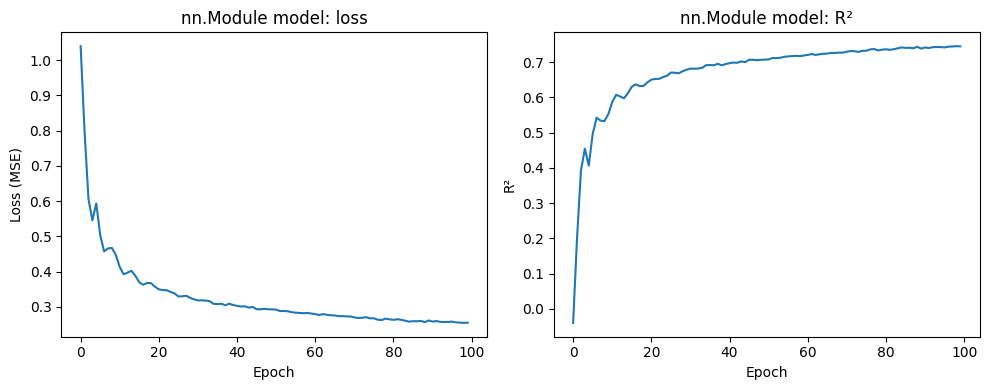

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('nn.Module model: loss')
axes[0].plot(functional_history['loss'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')

axes[1].set_title('nn.Module model: R²')
axes[1].plot(functional_history['r2'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

### 3.4. Test set evaluation

In [13]:
# Set model to evaluation mode
functional_model.eval()

# Make predictions (no gradient calculation needed)
with torch.no_grad():
    functional_predictions = functional_model(X_test).cpu().numpy().flatten()

# Calculate R²
ss_res = np.sum((testing_df[label].values - functional_predictions) ** 2)
ss_tot = np.sum((testing_df[label].values - np.mean(testing_df[label].values)) ** 2)
functional_rsquared = 1 - (ss_res / ss_tot)

print(f'nn.Module model R² on test set: {functional_rsquared:.4f}')

nn.Module model R² on test set: 0.7625


### 3.5. Performance analysis

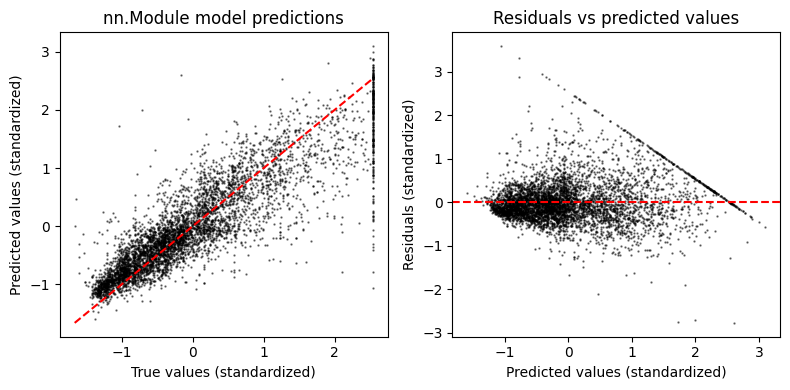

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].set_title('nn.Module model predictions')
axes[0].scatter(
    testing_df[label], functional_predictions,
    c='black', s=0.5, alpha=0.5
)
axes[0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)
axes[0].set_xlabel('True values (standardized)')
axes[0].set_ylabel('Predicted values (standardized)')

axes[1].set_title('Residuals vs predicted values')
axes[1].scatter(
    functional_predictions, testing_df[label] - functional_predictions,
    c='black', s=0.5, alpha=0.5
)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted values (standardized)')
axes[1].set_ylabel('Residuals (standardized)')

plt.tight_layout()
plt.show()

## 4. Model comparison

In [15]:
print(f'Sequential model R² on test set: {sequential_rsquared:.4f}')
print(f'nn.Module model R² on test set: {functional_rsquared:.4f}')

Sequential model R² on test set: 0.7670
nn.Module model R² on test set: 0.7625


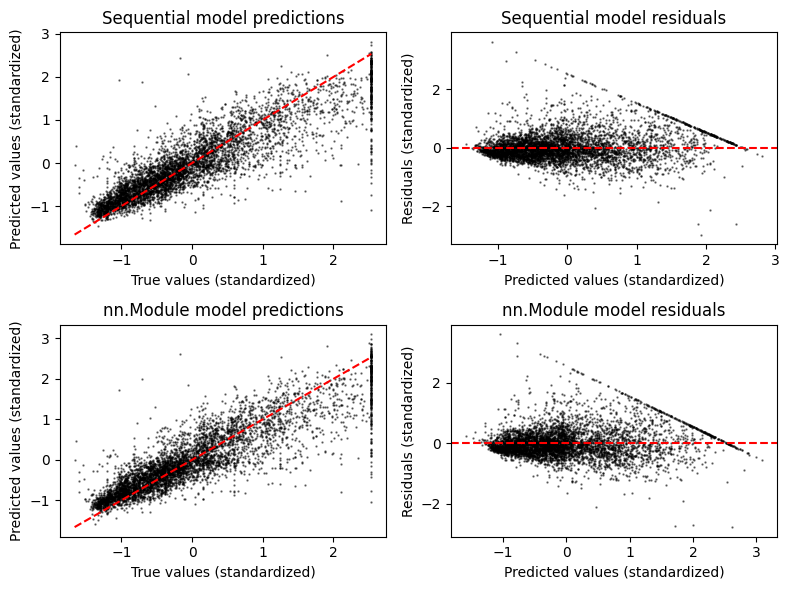

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Sequential model
axes[0, 0].set_title('Sequential model predictions')
axes[0, 0].scatter(
    testing_df[label], sequential_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[0, 0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)

axes[0, 0].set_xlabel('True values (standardized)')
axes[0, 0].set_ylabel('Predicted values (standardized)')

axes[0, 1].set_title('Sequential model residuals')
axes[0, 1].scatter(
    sequential_predictions, testing_df[label] - sequential_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Predicted values (standardized)')
axes[0, 1].set_ylabel('Residuals (standardized)')

# nn.Module model
axes[1, 0].set_title('nn.Module model predictions')
axes[1, 0].scatter(
    testing_df[label], functional_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[1, 0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)

axes[1, 0].set_xlabel('True values (standardized)')
axes[1, 0].set_ylabel('Predicted values (standardized)')

axes[1, 1].set_title('nn.Module model residuals')
axes[1, 1].scatter(
    functional_predictions, testing_df[label] - functional_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Predicted values (standardized)')
axes[1, 1].set_ylabel('Residuals (standardized)')

plt.tight_layout()
plt.show()